# Práctica 09 — Encoding avanzado y Target Encoding



## 0. Dependencias y configuración

In [2]:
import time
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import shap
from category_encoders import BinaryEncoder, TargetEncoder
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score
from sklearn.model_selection import StratifiedKFold, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import LabelEncoder, OneHotEncoder, OrdinalEncoder, StandardScaler

warnings.filterwarnings('ignore')
np.random.seed(42)
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('Set2')
print(' Entorno configurado para encoding avanzado')

 Entorno configurado para encoding avanzado


## 1. Carga y limpieza de Adult Income

In [3]:
url = 'https://archive.ics.uci.edu/ml/machine-learning-databases/adult/adult.data'
column_names = [
    'age', 'workclass', 'fnlwgt', 'education', 'education-num',
    'marital-status', 'occupation', 'relationship', 'race', 'sex',
    'capital-gain', 'capital-loss', 'hours-per-week',
    'native-country', 'income',
]
df = pd.read_csv(url, names=column_names, na_values='?', skipinitialspace=True)
for col in df.select_dtypes(include='object').columns:
    df[col] = df[col].str.strip()

missing_before = int(df.isna().sum().sum())
df = df.dropna(how='any').reset_index(drop=True)
df['target'] = (df['income'] == '>50K').astype(int)
categorical_cols = [c for c in df.select_dtypes('object').columns if c != 'income']
numeric_cols = [
    'age', 'fnlwgt', 'education-num', 'capital-gain',
    'capital-loss', 'hours-per-week',
]

print(f'Valores faltantes eliminados: {missing_before:,}')
print(f'Dimensiones finales: {df.shape}')
print(df['target'].value_counts(normalize=True).rename({0: '<=50K', 1: '>50K'}).round(4))
display(df.head())

Valores faltantes eliminados: 4,262
Dimensiones finales: (30162, 16)
target
<=50K    0.7511
>50K     0.2489
Name: proportion, dtype: float64


,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,income,target
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,<=50K,0
1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,<=50K,0
2,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,<=50K,0
3,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,<=50K,0
4,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba,<=50K,0


## 2. Análisis de cardinalidad

,categorías,grupo
native-country,41,media
education,16,media
occupation,14,media
workclass,7,baja
marital-status,7,baja
relationship,6,baja
race,5,baja
sex,2,baja


Baja cardinalidad: ['workclass', 'marital-status', 'relationship', 'race', 'sex']
Media cardinalidad: ['education', 'occupation', 'native-country']
Alta cardinalidad estricta: []
Columnas elegidas para Target Encoding: ['education', 'occupation', 'native-country']
One-hot completo produciría 90 columnas categóricas.


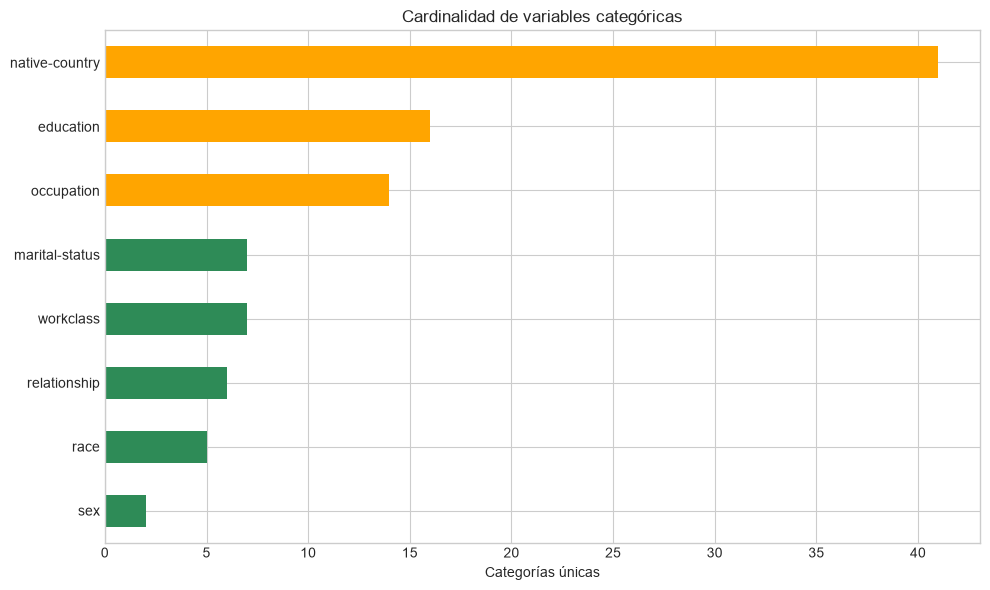

In [4]:
def classify_cardinality(dataframe, columns):
    low, medium, high = [], [], []
    for col in columns:
        n_unique = dataframe[col].nunique()
        if n_unique <= 10:
            low.append(col)
        elif n_unique <= 50:
            medium.append(col)
        else:
            high.append(col)
    return low, medium, high

low_card_cols, medium_card_cols, high_card_cols = classify_cardinality(df, categorical_cols)
target_card_cols = medium_card_cols + high_card_cols
cardinality = df[categorical_cols].nunique().sort_values(ascending=False)
cardinality_df = cardinality.to_frame('categorías')
cardinality_df['grupo'] = np.select(
    [cardinality_df['categorías'] <= 10, cardinality_df['categorías'] <= 50],
    ['baja', 'media'], default='alta',
)
display(cardinality_df)

onehot_columns = int(sum(df[c].nunique() - 1 for c in categorical_cols))
print(f'Baja cardinalidad: {low_card_cols}')
print(f'Media cardinalidad: {medium_card_cols}')
print(f'Alta cardinalidad estricta: {high_card_cols}')
print(f'Columnas elegidas para Target Encoding: {target_card_cols}')
print(f'One-hot completo produciría {onehot_columns} columnas categóricas.')

colors = cardinality_df['grupo'].map({'baja': 'seagreen', 'media': 'orange', 'alta': 'crimson'})
ax = cardinality.sort_values().plot.barh(figsize=(10, 6), color=colors.loc[cardinality.sort_values().index])
ax.set(title='Cardinalidad de variables categóricas', xlabel='Categorías únicas')
plt.tight_layout()
plt.show()

## 3. Preparación común

Se utiliza la misma partición estratificada para que la comparación entre métodos sea justa. El conjunto de prueba nunca participa del ajuste de los encoders.

In [5]:
all_features = categorical_cols + numeric_cols
X = df[all_features].copy()
y = df['target'].copy()
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y,
)
X_train, X_test = X_train.reset_index(drop=True), X_test.reset_index(drop=True)
y_train, y_test = y_train.reset_index(drop=True), y_test.reset_index(drop=True)

def evaluate_model(name, model, X_train_encoded, X_test_encoded, feature_names):
    start = time.perf_counter()
    model.fit(X_train_encoded, y_train)
    elapsed = time.perf_counter() - start
    pred = model.predict(X_test_encoded)
    proba = model.predict_proba(X_test_encoded)[:, 1]
    result = {
        'encoding': name,
        'accuracy': accuracy_score(y_test, pred),
        'auc': roc_auc_score(y_test, proba),
        'f1_score': f1_score(y_test, pred),
        'training_time': elapsed,
        'n_features': X_train_encoded.shape[1],
    }
    return result, model, list(feature_names)

print(f'Train: {X_train.shape} | Test: {X_test.shape}')

Train: (24129, 14) | Test: (6033, 14)


## 4. Experimento 1 — Label Encoding

In [6]:
X_train_label = X_train.copy()
X_test_label = X_test.copy()
label_encoders = {}
for col in categorical_cols:
    encoder = LabelEncoder()
    X_train_label[col] = encoder.fit_transform(X_train[col])
    mapping = dict(zip(encoder.classes_, encoder.transform(encoder.classes_)))
    X_test_label[col] = X_test[col].map(mapping).fillna(-1).astype(int)
    label_encoders[col] = encoder

model_label = RandomForestClassifier(n_estimators=150, random_state=42, n_jobs=-1)
results_label, model_label, names_label = evaluate_model(
    'Label Encoding', model_label, X_train_label, X_test_label, all_features,
)
display(pd.Series(results_label).to_frame('resultado'))

,resultado
encoding,Label Encoding
accuracy,0.852975
auc,0.902206
f1_score,0.68013
training_time,0.294769
n_features,14


Label Encoding es compacto, pero asigna un orden artificial. Los árboles toleran mejor este problema que los modelos lineales, aunque algunos cortes pueden agrupar categorías sin una relación semántica real. Las categorías nuevas se codifican como `-1`.

## 5. Experimento 2 — One-Hot Encoding de baja cardinalidad

In [7]:
onehot_encoder = OneHotEncoder(drop='first', sparse_output=False, handle_unknown='ignore')
train_ohe = onehot_encoder.fit_transform(X_train[low_card_cols])
test_ohe = onehot_encoder.transform(X_test[low_card_cols])
X_train_onehot = np.hstack([train_ohe, X_train[numeric_cols].to_numpy()])
X_test_onehot = np.hstack([test_ohe, X_test[numeric_cols].to_numpy()])
names_onehot = list(onehot_encoder.get_feature_names_out(low_card_cols)) + numeric_cols

model_onehot = RandomForestClassifier(n_estimators=150, random_state=42, n_jobs=-1)
results_onehot, model_onehot, names_onehot = evaluate_model(
    'One-Hot (baja cardinalidad)', model_onehot,
    X_train_onehot, X_test_onehot, names_onehot,
)
display(pd.Series(results_onehot).to_frame('resultado'))

,resultado
encoding,One-Hot (baja cardinalidad)
accuracy,0.845516
auc,0.895902
f1_score,0.663051
training_time,0.291822
n_features,28


Este experimento usa solo las categóricas de baja cardinalidad y las numéricas, tal como pide la consigna. `handle_unknown='ignore'` evita fallos ante categorías nuevas, representándolas con ceros en todas las columnas conocidas.

## 6. Experimento 3 — Target Encoding out-of-fold

In [8]:
def oof_target_encode(X_train, y_train, X_test, columns, smoothing=10.0, n_splits=5):
    encoded_train = pd.DataFrame(index=X_train.index, columns=columns, dtype=float)
    splitter = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=42)
    for fit_idx, valid_idx in splitter.split(X_train, y_train):
        fold_encoder = TargetEncoder(cols=columns, smoothing=smoothing)
        fold_encoder.fit(X_train.iloc[fit_idx][columns], y_train.iloc[fit_idx])
        encoded_train.iloc[valid_idx] = fold_encoder.transform(
            X_train.iloc[valid_idx][columns]
        ).to_numpy()
    final_encoder = TargetEncoder(cols=columns, smoothing=smoothing)
    final_encoder.fit(X_train[columns], y_train)
    encoded_test = final_encoder.transform(X_test[columns]).reset_index(drop=True)
    return encoded_train.astype(float), encoded_test.astype(float), final_encoder

train_target_cat, test_target_cat, target_encoder = oof_target_encode(
    X_train, y_train, X_test, target_card_cols, smoothing=10.0,
)
X_train_target = pd.concat([train_target_cat, X_train[numeric_cols]], axis=1)
X_test_target = pd.concat([test_target_cat, X_test[numeric_cols]], axis=1)
names_target = target_card_cols + numeric_cols
model_target = RandomForestClassifier(n_estimators=150, random_state=42, n_jobs=-1)
results_target, model_target, names_target = evaluate_model(
    'Target Encoding OOF', model_target, X_train_target, X_test_target, names_target,
)
display(pd.Series(results_target).to_frame('resultado'))
display(train_target_cat.describe().round(4))

,resultado
encoding,Target Encoding OOF
accuracy,0.831261
auc,0.85237
f1_score,0.596672
training_time,0.364928
n_features,9


,education,occupation,native-country
count,24129.0000,24129.0000,24129.0000
mean,0.2490,0.2489,0.2493
std,0.1568,0.1504,0.0412
min,0.0374,0.0002,0.0374
25%,0.1639,0.1331,0.2534
50%,0.2009,0.2337,0.2539
75%,0.4198,0.4428,0.2541
max,0.7603,0.4899,0.5124


El encoding de cada fila de entrenamiento se calcula con un encoder ajustado en otros folds; así, su propio target no participa del valor codificado. Para test se ajusta un encoder final usando todo train. El smoothing acerca categorías raras a la media global y reduce varianza.

## 7. Pipeline con branching — `ColumnTransformer`

In [9]:
preprocessor = ColumnTransformer(
    transformers=[
        ('low_card', OneHotEncoder(drop='first', sparse_output=False, handle_unknown='ignore'), low_card_cols),
        ('target_enc', TargetEncoder(cols=target_card_cols, smoothing=10.0), target_card_cols),
        ('numeric', StandardScaler(), numeric_cols),
    ],
    remainder='drop',
    verbose_feature_names_out=True,
)
pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', RandomForestClassifier(n_estimators=150, random_state=42, n_jobs=-1)),
])
start = time.perf_counter()
pipeline.fit(X_train, y_train)
pipeline_time = time.perf_counter() - start
pipeline_pred = pipeline.predict(X_test)
pipeline_proba = pipeline.predict_proba(X_test)[:, 1]
feature_names_out = list(pipeline.named_steps['preprocessor'].get_feature_names_out())
results_pipeline = {
    'encoding': 'Pipeline mixto',
    'accuracy': accuracy_score(y_test, pipeline_pred),
    'auc': roc_auc_score(y_test, pipeline_proba),
    'f1_score': f1_score(y_test, pipeline_pred),
    'training_time': pipeline_time,
    'n_features': len(feature_names_out),
}
print(f'Features originales: {len(all_features)}')
print(f'Features transformadas: {len(feature_names_out)}')
print(f'Columnas one-hot: {len(onehot_encoder.get_feature_names_out(low_card_cols))}')
display(pd.Series(results_pipeline).to_frame('resultado'))

Features originales: 14
Features transformadas: 31
Columnas one-hot: 22


,resultado
encoding,Pipeline mixto
accuracy,0.84966
auc,0.905504
f1_score,0.674327
training_time,0.327701
n_features,31


`ColumnTransformer` permite encapsular reglas distintas por grupo de columnas y aplicar exactamente la misma transformación en inferencia. El test queda fuera del ajuste. En un sistema especialmente sensible al sobreajuste, el target encoding del entrenamiento debería sustituirse por una variante OOF como la anterior o evaluarse dentro de validación cruzada anidada.

## 7.5. Explicabilidad — Feature Importance y SHAP

,feature,importance
26,numeric__fnlwgt,0.1655
25,numeric__age,0.1493
28,numeric__capital-gain,0.1011
7,low_card__marital-status_Married-civ-spouse,0.0929
23,target_enc__occupation,0.0860
30,numeric__hours-per-week,0.0820
22,target_enc__education,0.0642
27,numeric__education-num,0.0636
9,low_card__marital-status_Never-married,0.0334
29,numeric__capital-loss,0.0302


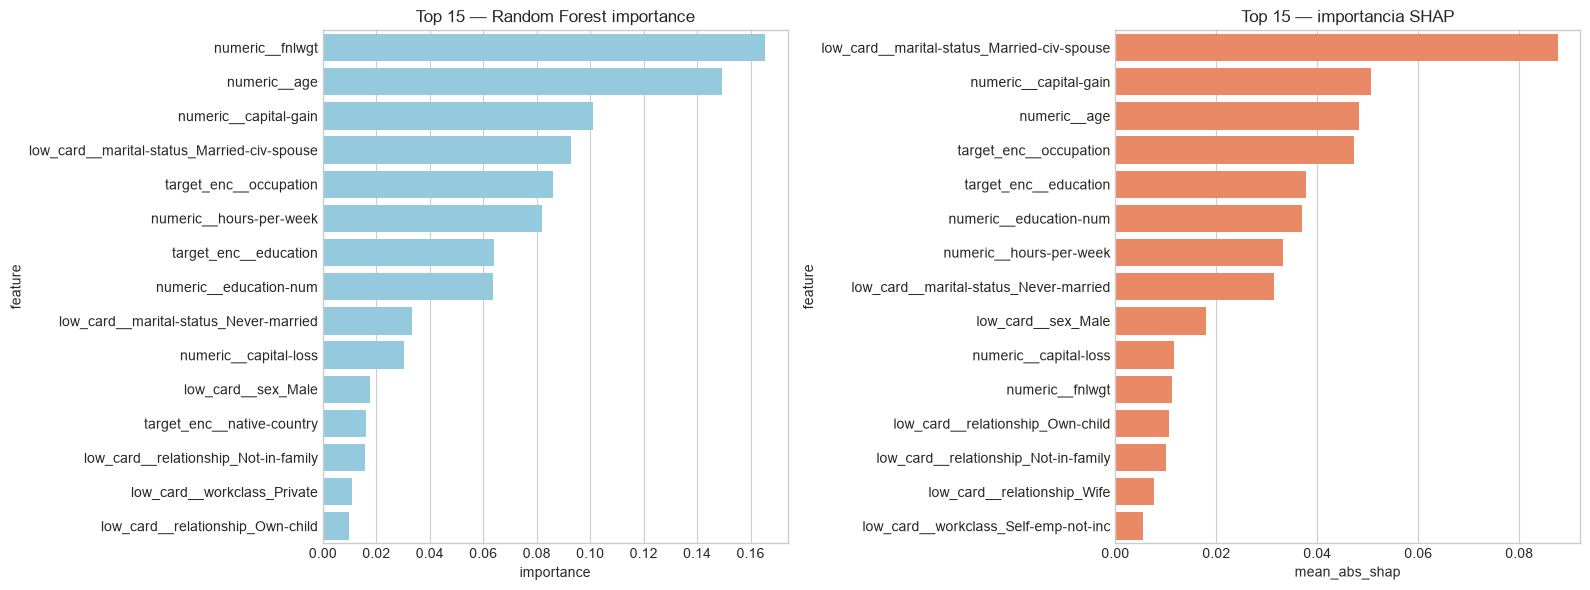

,feature,mean_abs_shap
7,low_card__marital-status_Married-civ-spouse,0.0876
28,numeric__capital-gain,0.0506
25,numeric__age,0.0482
23,target_enc__occupation,0.0473
22,target_enc__education,0.0377
27,numeric__education-num,0.0369
30,numeric__hours-per-week,0.0332
9,low_card__marital-status_Never-married,0.0315
21,low_card__sex_Male,0.0179
29,numeric__capital-loss,0.0115


,sum,mean,count
type,,,
Numérica,0.5916,0.0986,6
One-hot encoded,0.2419,0.0110,22
Target encoded,0.1664,0.0555,3


In [10]:
importance_df = pd.DataFrame({
    'feature': feature_names_out,
    'importance': pipeline.named_steps['classifier'].feature_importances_,
}).sort_values('importance', ascending=False)
display(importance_df.head(15).round(4))

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
sns.barplot(data=importance_df.head(15), x='importance', y='feature', ax=axes[0], color='skyblue')
axes[0].set_title('Top 15 — Random Forest importance')

X_test_transformed = pipeline.named_steps['preprocessor'].transform(X_test)
sample_size = min(400, len(X_test_transformed))
sample_idx = np.random.default_rng(42).choice(len(X_test_transformed), sample_size, replace=False)
X_shap = np.asarray(X_test_transformed)[sample_idx]
explainer = shap.TreeExplainer(pipeline.named_steps['classifier'])
shap_values_raw = explainer.shap_values(X_shap)
if isinstance(shap_values_raw, list):
    shap_values = np.asarray(shap_values_raw[1])
else:
    shap_array = np.asarray(shap_values_raw)
    shap_values = shap_array[:, :, 1] if shap_array.ndim == 3 else shap_array
shap_importance = pd.DataFrame({
    'feature': feature_names_out,
    'mean_abs_shap': np.abs(shap_values).mean(axis=0),
}).sort_values('mean_abs_shap', ascending=False)
sns.barplot(data=shap_importance.head(15), x='mean_abs_shap', y='feature', ax=axes[1], color='coral')
axes[1].set_title('Top 15 — importancia SHAP')
plt.tight_layout()
plt.show()
display(shap_importance.head(15).round(4))

def feature_type(name):
    if name.startswith('numeric__'):
        return 'Numérica'
    if name.startswith('target_enc__'):
        return 'Target encoded'
    return 'One-hot encoded'

type_importance = (importance_df.assign(type=importance_df['feature'].map(feature_type))
                   .groupby('type')['importance'].agg(['sum', 'mean', 'count'])
                   .sort_values('sum', ascending=False))
display(type_importance.round(4))

La importancia por impureza del bosque puede favorecer variables continuas o con muchos puntos de corte. SHAP aporta una segunda lectura basada en la contribución de cada variable a las predicciones. En un contexto real, variables como educación, estado civil, ocupación, edad, sexo o raza requieren además un análisis de equidad: importancia predictiva no equivale a causalidad ni justifica decisiones discriminatorias.

## 8. Comparación de resultados

,encoding,accuracy,auc,f1_score,training_time,n_features
0,Pipeline mixto,0.8497,0.9055,0.6743,0.3277,31
1,Label Encoding,0.8530,0.9022,0.6801,0.2948,14
2,One-Hot (baja cardinalidad),0.8455,0.8959,0.6631,0.2918,28
3,Target Encoding OOF,0.8313,0.8524,0.5967,0.3649,9


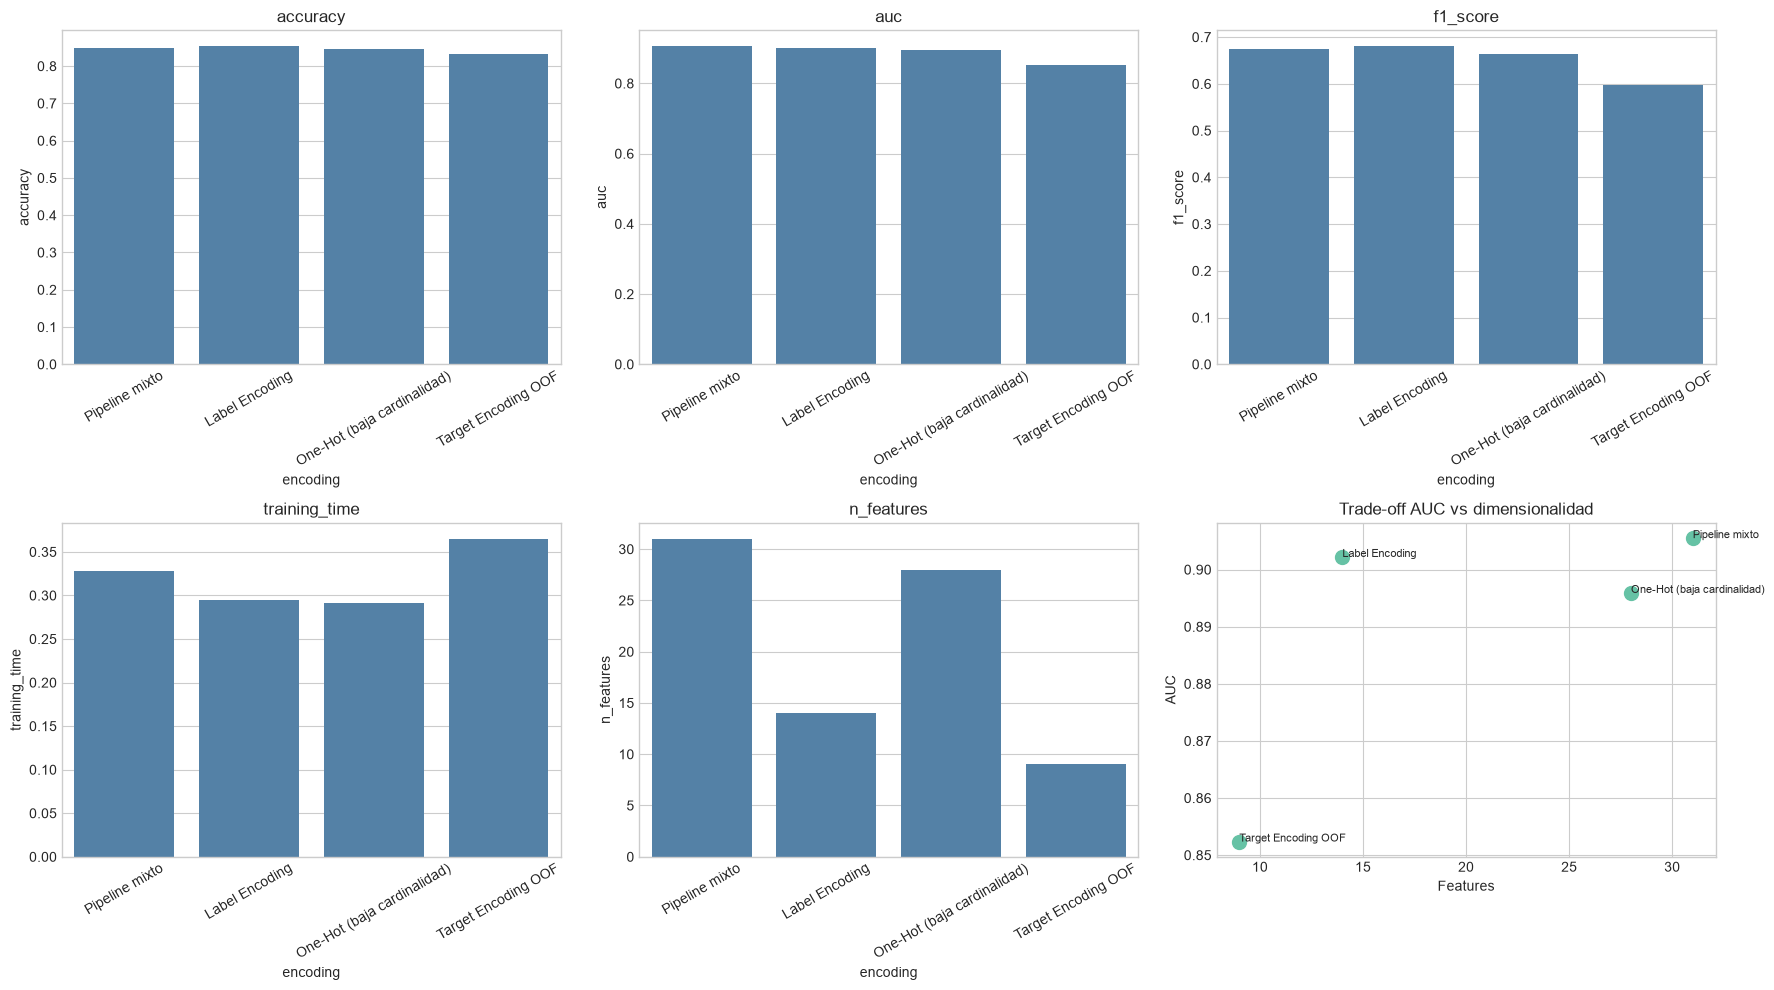

Mejor AUC: Pipeline mixto (0.9055)
Más rápido: One-Hot (baja cardinalidad) (0.292s)
Recomendación: priorizar AUC/F1 y estabilidad; validar latencia, memoria y fairness antes de producción.


In [11]:
results_df = pd.DataFrame([
    results_label, results_onehot, results_target, results_pipeline,
]).sort_values('auc', ascending=False).reset_index(drop=True)
display(results_df.round(4))

metric_cols = ['accuracy', 'auc', 'f1_score', 'training_time', 'n_features']
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
for ax, metric in zip(axes.ravel(), metric_cols):
    sns.barplot(data=results_df, x='encoding', y=metric, ax=ax, color='steelblue')
    ax.set_title(metric)
    ax.tick_params(axis='x', rotation=30)
axes[1, 2].scatter(results_df['n_features'], results_df['auc'], s=100)
for _, row in results_df.iterrows():
    axes[1, 2].annotate(row['encoding'], (row['n_features'], row['auc']), fontsize=8)
axes[1, 2].set(title='Trade-off AUC vs dimensionalidad', xlabel='Features', ylabel='AUC')
plt.tight_layout()
plt.show()

best_auc = results_df.loc[results_df['auc'].idxmax()]
fastest = results_df.loc[results_df['training_time'].idxmin()]
print(f"Mejor AUC: {best_auc['encoding']} ({best_auc['auc']:.4f})")
print(f"Más rápido: {fastest['encoding']} ({fastest['training_time']:.3f}s)")
print('Recomendación: priorizar AUC/F1 y estabilidad; validar latencia, memoria y fairness antes de producción.')

## 9. Investigación libre — técnicas adicionales

### 9.1 Frequency Encoding

In [12]:
def apply_frequency_encoding(train, test, columns):
    train_encoded = pd.DataFrame(index=train.index)
    test_encoded = pd.DataFrame(index=test.index)
    for col in columns:
        frequencies = train[col].value_counts(normalize=True)
        train_encoded[f'{col}_freq'] = train[col].map(frequencies)
        test_encoded[f'{col}_freq'] = test[col].map(frequencies).fillna(0)
    return train_encoded, test_encoded

train_freq, test_freq = apply_frequency_encoding(X_train, X_test, categorical_cols)
X_train_freq = pd.concat([train_freq, X_train[numeric_cols]], axis=1)
X_test_freq = pd.concat([test_freq, X_test[numeric_cols]], axis=1)
model_freq = RandomForestClassifier(n_estimators=150, random_state=42, n_jobs=-1)
results_freq, model_freq, names_freq = evaluate_model(
    'Frequency Encoding', model_freq, X_train_freq, X_test_freq, X_train_freq.columns,
)
display(pd.Series(results_freq).to_frame('resultado'))

,resultado
encoding,Frequency Encoding
accuracy,0.850986
auc,0.904777
f1_score,0.676269
training_time,0.291081
n_features,14


Frequency Encoding no usa el target, por lo que tiene menos riesgo de leakage; aun así, el mapa se aprende solo en train. Captura rareza/popularidad, pero categorías diferentes con igual frecuencia quedan indistinguibles.

### 9.2 Ordinal Encoding

In [13]:
education_order = [[
    'Preschool', '1st-4th', '5th-6th', '7th-8th', '9th', '10th',
    '11th', '12th', 'HS-grad', 'Some-college', 'Assoc-voc',
    'Assoc-acdm', 'Bachelors', 'Masters', 'Prof-school', 'Doctorate',
]]
ordinal_encoder = OrdinalEncoder(
    categories=education_order, handle_unknown='use_encoded_value', unknown_value=-1,
)
education_train_ordinal = ordinal_encoder.fit_transform(X_train[['education']]).ravel()
education_test_ordinal = ordinal_encoder.transform(X_test[['education']]).ravel()
ordinal_check = pd.DataFrame({
    'education': X_train['education'].head(10),
    'ordinal': education_train_ordinal[:10],
    'education-num': X_train['education-num'].head(10),
})
display(ordinal_check)
print('Correlación ordinal vs education-num:', np.corrcoef(education_train_ordinal, X_train['education-num'])[0, 1].round(4))

,education,ordinal,education-num
0,Bachelors,12.0,13
1,Some-college,9.0,10
2,Bachelors,12.0,13
3,Doctorate,15.0,16
4,Some-college,9.0,10
5,Some-college,9.0,10
6,Assoc-acdm,11.0,12
7,HS-grad,8.0,9
8,Some-college,9.0,10
9,Assoc-acdm,11.0,12


Correlación ordinal vs education-num: 1.0


Preservar el orden natural evita que el código sea arbitrario. En Adult Income, `education-num` ya representa prácticamente esa jerarquía; agregar ambas columnas sería redundante. El ordinal encoding es útil cuando el orden existe, especialmente en modelos lineales, pero las distancias entre niveles no siempre son uniformes.

### 9.3 Leave-One-Out Target Encoding

In [14]:
def leave_one_out_encoding(X, y, column):
    temporary = pd.DataFrame({'category': X[column].to_numpy(), 'target': y.to_numpy()})
    category_sum = temporary.groupby('category')['target'].transform('sum')
    category_count = temporary.groupby('category')['target'].transform('count')
    global_mean = y.mean()
    encoded = (category_sum - temporary['target']) / (category_count - 1)
    return encoded.where(category_count > 1, global_mean)

loo_demo = pd.DataFrame({
    'occupation': X_train['occupation'].head(10),
    'target': y_train.head(10),
    'occupation_loo': leave_one_out_encoding(X_train, y_train, 'occupation').head(10),
})
display(loo_demo.round(4))

,occupation,target,occupation_loo
0,Adm-clerical,0,0.1363
1,Adm-clerical,1,0.1360
2,Adm-clerical,0,0.1363
3,Prof-specialty,0,0.4477
4,Sales,0,0.2592
5,Adm-clerical,0,0.1363
6,Exec-managerial,1,0.4848
7,Adm-clerical,1,0.1360
8,Machine-op-inspct,0,0.1324
9,Sales,0,0.2592


Leave-One-Out excluye el target de la propia fila y reduce el sobreajuste directo. Aun así puede tener alta varianza en categorías pequeñas; smoothing, ruido controlado u OOF suelen ser más estables.

### 9.4 Binary Encoding

In [15]:
binary_encoder = BinaryEncoder(cols=categorical_cols, handle_unknown='value', handle_missing='value')
train_binary_cat = binary_encoder.fit_transform(X_train[categorical_cols])
test_binary_cat = binary_encoder.transform(X_test[categorical_cols])
X_train_binary = pd.concat([train_binary_cat.reset_index(drop=True), X_train[numeric_cols]], axis=1)
X_test_binary = pd.concat([test_binary_cat.reset_index(drop=True), X_test[numeric_cols]], axis=1)
model_binary = RandomForestClassifier(n_estimators=150, random_state=42, n_jobs=-1)
results_binary, model_binary, names_binary = evaluate_model(
    'Binary Encoding', model_binary, X_train_binary, X_test_binary, X_train_binary.columns,
)
print(f'Categorías originales: {len(categorical_cols)} | columnas binarias: {train_binary_cat.shape[1]}')
display(pd.Series(results_binary).to_frame('resultado'))

Categorías originales: 8 | columnas binarias: 29


,resultado
encoding,Binary Encoding
accuracy,0.8485
auc,0.901143
f1_score,0.671931
training_time,0.294561
n_features,35


Binary Encoding necesita aproximadamente $\lceil\log_2(N)\rceil$ bits por variable de $N$ categorías, por lo que reduce la dimensionalidad frente a one-hot. Es compacto y no usa el target, aunque los bits no poseen interpretación semántica directa.

### 9.5 Sensibilidad al smoothing

,smoothing,accuracy,auc,f1_score
0,1,0.8331,0.8510,0.5980
1,10,0.8291,0.8505,0.5907
2,100,0.8298,0.8493,0.5946
3,1000,0.8304,0.8519,0.5890


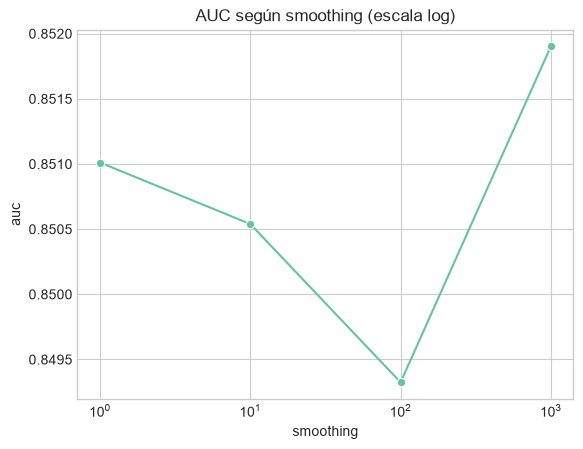

In [16]:
smoothing_results = []
for smoothing in [1, 10, 100, 1000]:
    tr_cat, te_cat, _ = oof_target_encode(
        X_train, y_train, X_test, target_card_cols, smoothing=smoothing,
    )
    tr = pd.concat([tr_cat, X_train[numeric_cols]], axis=1)
    te = pd.concat([te_cat, X_test[numeric_cols]], axis=1)
    smoothing_model = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
    smoothing_model.fit(tr, y_train)
    proba = smoothing_model.predict_proba(te)[:, 1]
    pred = smoothing_model.predict(te)
    smoothing_results.append({
        'smoothing': smoothing,
        'accuracy': accuracy_score(y_test, pred),
        'auc': roc_auc_score(y_test, proba),
        'f1_score': f1_score(y_test, pred),
    })
smoothing_df = pd.DataFrame(smoothing_results)
display(smoothing_df.round(4))
sns.lineplot(data=smoothing_df, x='smoothing', y='auc', marker='o')
plt.xscale('log')
plt.title('AUC según smoothing (escala log)')
plt.show()

Con smoothing bajo, la media de cada categoría pesa más; con smoothing alto, las categorías —especialmente las raras— se acercan a la media global. El valor se elige mediante validación, nunca mirando repetidamente el test en un proyecto real; aquí se usa el test solo con fines didácticos de la consigna.

## 10. Reflexión final

In [17]:
extended_results = pd.concat([
    results_df, pd.DataFrame([results_freq, results_binary])
], ignore_index=True).sort_values('auc', ascending=False)
display(extended_results.round(4))
winner = extended_results.iloc[0]
print(f"1. Mejor método por AUC: {winner['encoding']} ({winner['auc']:.4f}).")
print('2. El trade-off central es señal predictiva vs dimensionalidad, estabilidad, tiempo e interpretabilidad.')
print('3. Para prevenir leakage: split previo, encoders ajustados solo en train y Target Encoding OOF.')
print('4. One-hot es transparente pero crece con la cardinalidad; target, frequency y binary son alternativas compactas.')
print('5. ColumnTransformer centraliza ramas y garantiza transformaciones reproducibles en producción.')
print('6. La mayor dificultad fue comparar métodos con distinta información sin contaminar el conjunto de prueba.')
print('7. Próximos pasos: validación cruzada anidada, calibración, tuning y auditoría de fairness por grupo.')

,encoding,accuracy,auc,f1_score,training_time,n_features
0,Pipeline mixto,0.8497,0.9055,0.6743,0.3277,31
4,Frequency Encoding,0.8510,0.9048,0.6763,0.2911,14
1,Label Encoding,0.8530,0.9022,0.6801,0.2948,14
5,Binary Encoding,0.8485,0.9011,0.6719,0.2946,35
2,One-Hot (baja cardinalidad),0.8455,0.8959,0.6631,0.2918,28
3,Target Encoding OOF,0.8313,0.8524,0.5967,0.3649,9


1. Mejor método por AUC: Pipeline mixto (0.9055).
2. El trade-off central es señal predictiva vs dimensionalidad, estabilidad, tiempo e interpretabilidad.
3. Para prevenir leakage: split previo, encoders ajustados solo en train y Target Encoding OOF.
4. One-hot es transparente pero crece con la cardinalidad; target, frequency y binary son alternativas compactas.
5. ColumnTransformer centraliza ramas y garantiza transformaciones reproducibles en producción.
6. La mayor dificultad fue comparar métodos con distinta información sin contaminar el conjunto de prueba.
7. Próximos pasos: validación cruzada anidada, calibración, tuning y auditoría de fairness por grupo.


### Conclusiones

- **Comparación:** el mejor método debe elegirse por la métrica relevante y su variabilidad en validación, no por una única partición. AUC compara ranking; F1 es útil cuando interesa equilibrar precisión y recall de la clase `>50K`.
- **Producción:** el pipeline mixto es la estructura más mantenible, pero conviene incorporar Target Encoding OOF durante entrenamiento y monitorear categorías nuevas.
- **Data leakage:** calcular promedios de target con la misma observación infla la señal, sobre todo en categorías raras. Split previo, OOF y smoothing reducen el riesgo.
- **Alta cardinalidad:** one-hot aumenta memoria y dispersión; target encoding condensa señal, frequency no usa el target y binary ofrece dimensionalidad logarítmica.
- **Responsabilidad:** el dataset contiene atributos sensibles y refleja un censo de 1994. Antes de cualquier uso real hay que analizar sesgo, desempeño por subgrupo, legalidad y consecuencias de la decisión.